In [1]:
RANDOM_STATE = 42
OUT_DIR = "runs"
RUN_NAME = "blte"

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import seaborn as sns




DATA_PATH = r"D:\elliptic\blte\Labeled-Transactions-based-Dataset-of-Ethereum-Network-master\FinalDataset.xlsx"


In [3]:

df = pd.read_excel(DATA_PATH)

print("Number of data points:", len(df))
print("features:", df.columns.tolist())

Number of data points: 71250
features: ['hash', 'nonce', 'transaction_index', 'from_address', 'to_address', 'value', 'gas', 'gas_price', 'input', 'receipt_cumulative_gas_used', 'receipt_gas_used', 'block_timestamp', 'block_number', 'block_hash', 'from_scam', 'to_scam', 'from_category', 'to_category']


In [4]:
df['rcpt_cum_gas_used'] = df['receipt_cumulative_gas_used']
df = df.drop(columns='receipt_cumulative_gas_used')

In [5]:

for col in ["from_scam", "to_scam"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)


df["label"] = (
    (df.get("from_scam", 0) == 1) |
    (df.get("to_scam", 0) == 1)
).astype(int)

LABEL_COL = "label"

print("Label distribution  (0=normal, 1=abnormal):")
print(df[LABEL_COL].value_counts())

y = df[LABEL_COL].values

Label distribution  (0=normal, 1=abnormal):
label
0    57000
1    14250
Name: count, dtype: int64


In [6]:

ts_col = None
for c in ["block_timestamp", "block_number"]:
    if c in df.columns:
        ts_col = c
        break


ts_raw = df[ts_col].copy()

if ts_col == "block_timestamp":
    ts_dt = pd.to_datetime(ts_raw, errors="coerce")

    ts_dt = ts_dt.fillna(method="ffill").fillna(method="bfill")
    ts_num = (ts_dt.view("int64") // 10**9).astype("int64")
else:
    ts_num = pd.to_numeric(ts_raw, errors="coerce")
    ts_num = ts_num.fillna(method="ffill").fillna(method="bfill").astype("int64")

drop_id_cols = [

    'block_timestamp',   
    'txId',

    "hash",
    'transaction_index',
    "from_address",
    "to_address",
    "block_hash",
    "input"
]

drop_label_cols = [
    "from_scam", "to_scam",
    "from_category", "to_category",
    LABEL_COL
]

cols_to_drop = [c for c in drop_id_cols + drop_label_cols if c in df.columns]

feature_candidates = [c for c in df.columns if c not in cols_to_drop]
X_df = df[feature_candidates].copy()


non_numeric = X_df.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print("Drop non-numeric columns:", non_numeric)
    X_df = X_df.drop(columns=non_numeric)

feature_cols = X_df.columns.tolist()
print("Training features:", feature_cols)

X = X_df.values


if "txId" in df.columns:
    txid = df.loc[X_df.index, "txId"].astype(int).values
else:
    txid = np.arange(len(X_df), dtype=int)
print("txid shape:", txid.shape)


ts_num = ts_num.loc[X_df.index].to_numpy()


Training features: ['nonce', 'value', 'gas', 'gas_price', 'receipt_gas_used', 'block_number', 'rcpt_cum_gas_used']
txid shape: (71250,)


C:\Users\Admin\AppData\Local\Temp\ipykernel_25636\3706014679.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts_dt = ts_dt.fillna(method="ffill").fillna(method="bfill")
C:\Users\Admin\AppData\Local\Temp\ipykernel_25636\3706014679.py:14: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  ts_num = (ts_dt.view("int64") // 10**9).astype("int64")


In [7]:

corr_df = pd.concat(
    [
        X_df.reset_index(drop=True),
        df[LABEL_COL].reset_index(drop=True)
    ],
    axis=1
)


corr_matrix = corr_df.corr()


corr_with_label = corr_matrix[LABEL_COL].drop(labels=[LABEL_COL])


corr_with_label_abs = corr_with_label.abs().sort_values(ascending=False)

print("\nTop 30 features with the largest absolute correlation (|corr|) with the label:")
print(corr_with_label_abs.head(30))


corr_table = pd.DataFrame({
    "corr": corr_with_label,
    "abs_corr": corr_with_label_abs
}).sort_values("abs_corr", ascending=False)

corr_table.head(30)



Top 30 features with the largest absolute correlation (|corr|) with the label:
block_number         0.442214
nonce                0.120640
rcpt_cum_gas_used    0.110460
receipt_gas_used     0.105110
gas_price            0.048455
gas                  0.022670
value                0.015716
Name: label, dtype: float64


,corr,abs_corr
block_number,0.442214,0.442214
nonce,-0.120640,0.120640
rcpt_cum_gas_used,0.110460,0.110460
receipt_gas_used,0.105110,0.105110
gas_price,-0.048455,0.048455
gas,0.022670,0.022670
value,-0.015716,0.015716


In [8]:


TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9



unique_ts = np.sort(np.unique(ts_num))
n_ts = len(unique_ts)



train_cut = int(np.floor(TRAIN_RATIO * n_ts))
val_cut   = int(np.floor((TRAIN_RATIO + VAL_RATIO) * n_ts))

train_cut = max(train_cut, 1)
val_cut   = max(val_cut, train_cut + 1)
val_cut   = min(val_cut, n_ts - 1)

train_ts = unique_ts[:train_cut]
val_ts   = unique_ts[train_cut:val_cut]
test_ts  = unique_ts[val_cut:]

train_mask = np.isin(ts_num, train_ts)
val_mask   = np.isin(ts_num, val_ts)
test_mask  = np.isin(ts_num, test_ts)


assert not np.any(train_mask & val_mask)
assert not np.any(train_mask & test_mask)
assert not np.any(val_mask & test_mask)
assert np.all(train_mask | val_mask | test_mask)

X_train, y_train, txid_train = X[train_mask], y[train_mask], txid[train_mask]
X_val,   y_val,   txid_val   = X[val_mask],   y[val_mask],   txid[val_mask]
X_test,  y_test,  txid_test  = X[test_mask],  y[test_mask],  txid[test_mask]

def show_stats(name, yy):
    counts = np.bincount(yy)
    n0 = counts[0] if len(counts) > 0 else 0
    n1 = counts[1] if len(counts) > 1 else 0
    ratio = n1 / (n0 + n1) if (n0 + n1) > 0 else 0
    print(f"{name:5s}: 0 = {n0:6d}, 1 = {n1:6d}, scam_ratio = {ratio:.6f}")

print("\n=== Label distribution ===")
show_stats("ALL",   y)
show_stats("Train", y_train)
show_stats("Val",   y_val)
show_stats("Test",  y_test)

print("\nKích thước:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)



=== Label distribution ===
ALL  : 0 =  57000, 1 =  14250, scam_ratio = 0.200000
Train: 0 =  42538, 1 =   3021, scam_ratio = 0.066310
Val  : 0 =   7200, 1 =    699, scam_ratio = 0.088492
Test : 0 =   7262, 1 =  10530, scam_ratio = 0.591839

Kích thước:
X_train: (45559, 7) y_train: (45559,)
X_val  : (7899, 7) y_val  : (7899,)
X_test : (17792, 7) y_test : (17792,)


In [9]:
print("Training feature:", feature_cols)


Training feature: ['nonce', 'value', 'gas', 'gas_price', 'receipt_gas_used', 'block_number', 'rcpt_cum_gas_used']


In [10]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [11]:

import os
import numpy as np

def load_saved_proba(save_dirs, filename, txid_test, fill=0.5):

    for d in save_dirs:
        f = os.path.join(d, filename)
        if os.path.exists(f):
            npz = np.load(f, allow_pickle=True)
            txid = npz["txid"].astype(int)
            proba = npz["proba"].astype(float)
            thr = float(npz["threshold"]) if "threshold" in npz.files else 0.5

            mp = {int(t): float(p) for t, p in zip(txid.tolist(), proba.tolist())}
            aligned = np.array([mp.get(int(t), np.nan) for t in txid_test], dtype=float)

            missing = int(np.isnan(aligned).sum())
            if missing > 0:
                print(f"[WARN] Missing {missing}/{len(aligned)} txId in {f}. Fill={fill}")
                aligned = np.nan_to_num(aligned, nan=fill)

            return aligned, thr, f

    return None, 0.5, None

GNN_SAVE_CANDIDATES = [
    "gnn_saved",
    r"D:\elliptic\blte\blte\gnn_saved",
]
gnn_proba_test, gnn_threshold, gnn_file = load_saved_proba(
    GNN_SAVE_CANDIDATES, "gnn_test_preds.npz", txid_test, fill=0.5
)
if gnn_proba_test is not None:
    print("[OK] Loaded GNN preds:", gnn_proba_test.shape, "| thr:", gnn_threshold, "| file:", gnn_file)



SAGE_SAVE_CANDIDATES = [
    "sage_saved",
    r"D:\elliptic\blte\blte\sage_saved",
]
sage_proba_test, sage_threshold, sage_file = load_saved_proba(
    SAGE_SAVE_CANDIDATES, "gnn_test_preds.npz", txid_test, fill=0.5
)
if sage_proba_test is not None:
    print("[OK] Loaded SAGE preds:", sage_proba_test.shape, "| thr:", sage_threshold, "| file:", sage_file)



[OK] Loaded GNN preds: (17792,) | thr: 0.55 | file: gnn_saved\gnn_test_preds.npz
[OK] Loaded SAGE preds: (17792,) | thr: 0.5 | file: sage_saved\gnn_test_preds.npz


In [12]:
print("Train size:", X_train_scaled.shape, "Val size:", X_val_scaled.shape, "Test size:", X_test_scaled.shape)


print("Số nhãn train:", np.bincount(y_train))
print("Số nhãn val  :", np.bincount(y_val))
print("Số nhãn test :", np.bincount(y_test))


Train size: (45559, 7) Val size: (7899, 7) Test size: (17792, 7)
Số nhãn train: [42538  3021]
Số nhãn val  : [7200  699]
Số nhãn test : [ 7262 10530]


In [13]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from scipy.stats import randint, uniform

def sample_param(dist, rng):

    if hasattr(dist, "rvs"):
        return dist.rvs(random_state=rng)
    # nếu là list/tuple
    dist = list(dist)
    return dist[rng.randint(0, len(dist))]

def random_search_single_model(name, base_estimator, param_dist,
                               X_train, y_train, X_val, y_val,
                               n_iter=30):
    print(f"\n===== Random search for {name}  =====")
    rng = np.random.RandomState(RANDOM_STATE)
    best_f1 = -1.0
    best_params = None

    for i in range(n_iter):

        params = {k: sample_param(v, rng) for k, v in param_dist.items()}

        model = clone(base_estimator)
        model.set_params(**params)
        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)
        f1 = f1_score(y_val, y_val_pred)

        print(f"Iter {i+1:02d}/{n_iter}: F1(val) = {f1:.6f}, params = {params}")

        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    print(f"\n>>> {name} – best F1(val) = {best_f1:.6f}")
    print("Best params:", best_params)

    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])

    best_model = clone(base_estimator)
    best_model.set_params(**best_params)
    best_model.fit(X_train_full, y_train_full)

    return best_model


In [14]:

n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0
print("scale_pos_weight (train):", scale_pos_weight)

scale_pos_weight (train): 14.080767957629924


7. AutoML cho RF / XGB / LGBM

In [15]:

# 1) RandomForest
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_param_dist = {
    "n_estimators": randint(200, 600),
    "max_depth": randint(3, 30),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"],
    # thêm criterion vào hyperparameter search
    "criterion": ["gini", "entropy"],  # nếu sklearn mới có thể thêm "log_loss"
}


best_rf = random_search_single_model(
    "RandomForest",
    rf_base,
    rf_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30
)


===== Random search for RandomForest  =====
Iter 01/30: F1(val) = 0.764940, params = {'n_estimators': 302, 'max_depth': 22, 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': None, 'class_weight': 'balanced', 'criterion': 'gini'}
Iter 02/30: F1(val) = 0.758733, params = {'n_estimators': 220, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 11, 'max_features': None, 'class_weight': 'balanced', 'criterion': 'gini'}
Iter 03/30: F1(val) = 0.646660, params = {'n_estimators': 299, 'max_depth': 10, 'min_samples_split': 25, 'min_samples_leaf': 3, 'max_features': 'log2', 'class_weight': None, 'criterion': 'entropy'}
Iter 04/30: F1(val) = 0.709793, params = {'n_estimators': 543, 'max_depth': 14, 'min_samples_split': 31, 'min_samples_leaf': 6, 'max_features': 'log2', 'class_weight': 'balanced', 'criterion': 'entropy'}
Iter 05/30: F1(val) = 0.539185, params = {'n_estimators': 476, 'max_depth': 3, 'min_samples_split': 13, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'c

In [16]:
# 2) XGBoost
xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    tree_method="hist",   
    eval_metric="logloss",
    use_label_encoder=False
)
xgb_param_dist = {
    "n_estimators": randint(300, 800),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),      
    "colsample_bytree": uniform(0.6, 0.4),  
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "reg_lambda": uniform(0, 5),
    "objective": ["binary:logistic"],      
    "eval_metric": ["logloss", "aucpr"],   
}

best_xgb = random_search_single_model(
    "XGBoost",
    xgb_base,
    xgb_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30
)


===== Random search for XGBoost  =====


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 01/30: F1(val) = 0.685446, params = {'n_estimators': 402, 'max_depth': 6, 'learning_rate': np.float64(0.20014286128198325), 'subsample': np.float64(0.892797576724562), 'colsample_bytree': np.float64(0.8394633936788146), 'min_child_weight': 7, 'gamma': np.float64(2.229163764267956), 'reg_lambda': np.float64(0.4998745790900144), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 02/30: F1(val) = 0.657061, params = {'n_estimators': 387, 'max_depth': 7, 'learning_rate': np.float64(0.13022300234864176), 'subsample': np.float64(0.8832290311184181), 'colsample_bytree': np.float64(0.608233797718321), 'min_child_weight': 2, 'gamma': np.float64(3.609993861334124), 'reg_lambda': np.float64(4.692763545078751), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 03/30: F1(val) = 0.701012, params = {'n_estimators': 491, 'max_depth': 6, 'learning_rate': np.float64(0.046680901970686764), 'subsample': np.float64(0.7216968971838151), 'colsample_bytree': np.float64(0.8099025726528951), 'min_child_weight': 9, 'gamma': np.float64(1.4561457009902097), 'reg_lambda': np.float64(3.0592644736118975), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 04/30: F1(val) = 0.685446, params = {'n_estimators': 775, 'max_depth': 6, 'learning_rate': np.float64(0.08327236865873834), 'subsample': np.float64(0.7824279936868144), 'colsample_bytree': np.float64(0.9140703845572055), 'min_child_weight': 3, 'gamma': np.float64(1.9123099563358137), 'reg_lambda': np.float64(4.916154429033941), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 05/30: F1(val) = 0.700093, params = {'n_estimators': 430, 'max_depth': 7, 'learning_rate': np.float64(0.1315089703802877), 'subsample': np.float64(0.6682096494749166), 'colsample_bytree': np.float64(0.6260206371941118), 'min_child_weight': 4, 'gamma': np.float64(4.711008778424263), 'reg_lambda': np.float64(2.8164410892276965), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 06/30: F1(val) = 0.639456, params = {'n_estimators': 564, 'max_depth': 4, 'learning_rate': np.float64(0.02953442280127678), 'subsample': np.float64(0.8736932106048627), 'colsample_bytree': np.float64(0.7760609974958406), 'min_child_weight': 7, 'gamma': np.float64(3.0499832889131047), 'reg_lambda': np.float64(4.165974558680822), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 07/30: F1(val) = 0.649376, params = {'n_estimators': 505, 'max_depth': 3, 'learning_rate': np.float64(0.061755996320003385), 'subsample': np.float64(0.8650089137415928), 'colsample_bytree': np.float64(0.7246844304357644), 'min_child_weight': 6, 'gamma': np.float64(1.039708314340944), 'reg_lambda': np.float64(2.8385016390999573), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 08/30: F1(val) = 0.642857, params = {'n_estimators': 490, 'max_depth': 4, 'learning_rate': np.float64(0.16502656467222293), 'subsample': np.float64(0.9757995766256756), 'colsample_bytree': np.float64(0.9579309401710595), 'min_child_weight': 8, 'gamma': np.float64(2.852219872026997), 'reg_lambda': np.float64(2.6041713001291185), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 09/30: F1(val) = 0.723327, params = {'n_estimators': 595, 'max_depth': 7, 'learning_rate': np.float64(0.0877354579378964), 'subsample': np.float64(0.7085396127095583), 'colsample_bytree': np.float64(0.9314950036607718), 'min_child_weight': 9, 'gamma': np.float64(1.4046725484369038), 'reg_lambda': np.float64(2.7134804157912424), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 10/30: F1(val) = 0.657061, params = {'n_estimators': 456, 'max_depth': 9, 'learning_rate': np.float64(0.0430533878126005), 'subsample': np.float64(0.6062545626964776), 'colsample_bytree': np.float64(0.7693605922825478), 'min_child_weight': 1, 'gamma': np.float64(0.993578407670862), 'reg_lambda': np.float64(0.027610585618011996), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 11/30: F1(val) = 0.648184, params = {'n_estimators': 798, 'max_depth': 3, 'learning_rate': np.float64(0.15226839054973001), 'subsample': np.float64(0.9160702162124823), 'colsample_bytree': np.float64(0.8423839899124046), 'min_child_weight': 7, 'gamma': np.float64(3.2553851275097223), 'reg_lambda': np.float64(4.574798377718904), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 12/30: F1(val) = 0.678538, params = {'n_estimators': 627, 'max_depth': 6, 'learning_rate': np.float64(0.07617960497052984), 'subsample': np.float64(0.6254233401144095), 'colsample_bytree': np.float64(0.7243929286862649), 'min_child_weight': 8, 'gamma': np.float64(3.329611783087483), 'reg_lambda': np.float64(2.9564889385386355), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 13/30: F1(val) = 0.653257, params = {'n_estimators': 774, 'max_depth': 5, 'learning_rate': np.float64(0.10444298503238986), 'subsample': np.float64(0.6478376983753207), 'colsample_bytree': np.float64(0.885297914889198), 'min_child_weight': 1, 'gamma': np.float64(3.608647605824366), 'reg_lambda': np.float64(1.1799245987447788), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 14/30: F1(val) = 0.696462, params = {'n_estimators': 658, 'max_depth': 5, 'learning_rate': np.float64(0.11454656587639882), 'subsample': np.float64(0.7710164073434198), 'colsample_bytree': np.float64(0.610167650697638), 'min_child_weight': 3, 'gamma': np.float64(0.15714592843367126), 'reg_lambda': np.float64(3.182052056318902), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 15/30: F1(val) = 0.663480, params = {'n_estimators': 395, 'max_depth': 6, 'learning_rate': np.float64(0.1915132947852186), 'subsample': np.float64(0.69971689165955), 'colsample_bytree': np.float64(0.7641531692142519), 'min_child_weight': 4, 'gamma': np.float64(4.714267852789905), 'reg_lambda': np.float64(2.99432733244268), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 16/30: F1(val) = 0.698795, params = {'n_estimators': 385, 'max_depth': 6, 'learning_rate': np.float64(0.19593953046851464), 'subsample': np.float64(0.9232481518257668), 'colsample_bytree': np.float64(0.8533615026041694), 'min_child_weight': 6, 'gamma': np.float64(2.282672852414551), 'reg_lambda': np.float64(1.092202186084168), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 17/30: F1(val) = 0.676749, params = {'n_estimators': 585, 'max_depth': 8, 'learning_rate': np.float64(0.11786844838313014), 'subsample': np.float64(0.922976062065625), 'colsample_bytree': np.float64(0.9584365199693973), 'min_child_weight': 7, 'gamma': np.float64(4.53414220772877), 'reg_lambda': np.float64(1.3606612469231765), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 18/30: F1(val) = 0.651252, params = {'n_estimators': 745, 'max_depth': 3, 'learning_rate': np.float64(0.17360295318449864), 'subsample': np.float64(0.9442922333025374), 'colsample_bytree': np.float64(0.6027808522124762), 'min_child_weight': 8, 'gamma': np.float64(2.6704470968772096), 'reg_lambda': np.float64(2.424149856794916), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 19/30: F1(val) = 0.646776, params = {'n_estimators': 606, 'max_depth': 4, 'learning_rate': np.float64(0.07752303428072559), 'subsample': np.float64(0.9771638815650077), 'colsample_bytree': np.float64(0.7292811728083021), 'min_child_weight': 8, 'gamma': np.float64(3.515094794475889), 'reg_lambda': np.float64(1.81814801189647), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 20/30: F1(val) = 0.698236, params = {'n_estimators': 741, 'max_depth': 6, 'learning_rate': np.float64(0.05937521256772024), 'subsample': np.float64(0.8785217091359153), 'colsample_bytree': np.float64(0.8849082359697769), 'min_child_weight': 5, 'gamma': np.float64(1.424202471887338), 'reg_lambda': np.float64(0.18443473677266398), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 21/30: F1(val) = 0.651252, params = {'n_estimators': 301, 'max_depth': 4, 'learning_rate': np.float64(0.09220740266364626), 'subsample': np.float64(0.6132202931602193), 'colsample_bytree': np.float64(0.7380284992106732), 'min_child_weight': 1, 'gamma': np.float64(1.197809453334862), 'reg_lambda': np.float64(0.7244743604561155), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 22/30: F1(val) = 0.684854, params = {'n_estimators': 517, 'max_depth': 8, 'learning_rate': np.float64(0.058411054302300085), 'subsample': np.float64(0.8688542189623514), 'colsample_bytree': np.float64(0.9046478461314871), 'min_child_weight': 1, 'gamma': np.float64(3.641081743059298), 'reg_lambda': np.float64(1.838915663596266), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 23/30: F1(val) = 0.709441, params = {'n_estimators': 397, 'max_depth': 8, 'learning_rate': np.float64(0.08976488848891061), 'subsample': np.float64(0.9265727492877536), 'colsample_bytree': np.float64(0.9193380499938204), 'min_child_weight': 9, 'gamma': np.float64(1.6039003248586792), 'reg_lambda': np.float64(0.9325925519992712), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:29:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 24/30: F1(val) = 0.690233, params = {'n_estimators': 558, 'max_depth': 6, 'learning_rate': np.float64(0.07519178104037695), 'subsample': np.float64(0.6880964190262193), 'colsample_bytree': np.float64(0.884459812975207), 'min_child_weight': 3, 'gamma': np.float64(1.7433299364586468), 'reg_lambda': np.float64(0.4808827554571038), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 25/30: F1(val) = 0.732496, params = {'n_estimators': 716, 'max_depth': 9, 'learning_rate': np.float64(0.19734599774734693), 'subsample': np.float64(0.6550083776583973), 'colsample_bytree': np.float64(0.7364265404201034), 'min_child_weight': 9, 'gamma': np.float64(1.0453581036885684), 'reg_lambda': np.float64(2.707239869137829), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 26/30: F1(val) = 0.658349, params = {'n_estimators': 398, 'max_depth': 9, 'learning_rate': np.float64(0.14199680920683583), 'subsample': np.float64(0.9268888800804863), 'colsample_bytree': np.float64(0.822080324639785), 'min_child_weight': 1, 'gamma': np.float64(1.2092614545022584), 'reg_lambda': np.float64(0.46551383902949606), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 27/30: F1(val) = 0.682331, params = {'n_estimators': 752, 'max_depth': 7, 'learning_rate': np.float64(0.18652726863786795), 'subsample': np.float64(0.6754828433365517), 'colsample_bytree': np.float64(0.7115485410368727), 'min_child_weight': 3, 'gamma': np.float64(3.629778394351197), 'reg_lambda': np.float64(4.485551299762886), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 28/30: F1(val) = 0.655139, params = {'n_estimators': 353, 'max_depth': 3, 'learning_rate': np.float64(0.13840632923085758), 'subsample': np.float64(0.6336559859980195), 'colsample_bytree': np.float64(0.6646514856378455), 'min_child_weight': 6, 'gamma': np.float64(3.344941273571143), 'reg_lambda': np.float64(2.9034331071822734), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 29/30: F1(val) = 0.681132, params = {'n_estimators': 772, 'max_depth': 5, 'learning_rate': np.float64(0.2047327673510635), 'subsample': np.float64(0.7135683898949863), 'colsample_bytree': np.float64(0.7221455441377573), 'min_child_weight': 2, 'gamma': np.float64(3.459475988463466), 'reg_lambda': np.float64(3.259806297513003), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Iter 30/30: F1(val) = 0.630137, params = {'n_estimators': 783, 'max_depth': 3, 'learning_rate': np.float64(0.013615072723104174), 'subsample': np.float64(0.7975574860733738), 'colsample_bytree': np.float64(0.6715290836885315), 'min_child_weight': 8, 'gamma': np.float64(3.2481644952360735), 'reg_lambda': np.float64(4.24611705247089), 'objective': 'binary:logistic', 'eval_metric': 'logloss'}

>>> XGBoost – best F1(val) = 0.732496
Best params: {'n_estimators': 716, 'max_depth': 9, 'learning_rate': np.float64(0.19734599774734693), 'subsample': np.float64(0.6550083776583973), 'colsample_bytree': np.float64(0.7364265404201034), 'min_child_weight': 9, 'gamma': np.float64(1.0453581036885684), 'reg_lambda': np.float64(2.707239869137829), 'objective': 'binary:logistic', 'eval_metric': 'aucpr'}


d:\elliptic\venv1\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:30:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [17]:
# 3) LightGBM
lgbm_base = LGBMClassifier(
    random_state=RANDOM_STATE,
    objective="binary",
    n_jobs=-1
)
lgbm_param_dist = {
    "n_estimators": randint(300, 800),
    "num_leaves": randint(15, 255),
    "max_depth": randint(-1, 12),         
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),       
    "colsample_bytree": uniform(0.6, 0.4),  
    "min_child_samples": randint(10, 100),
    "reg_lambda": uniform(0, 5),

    "objective": ["binary"],                   
    "metric": ["binary_logloss", "auc", "aucpr"]  
}

best_lgbm = random_search_single_model(
    "LightGBM",
    lgbm_base,
    lgbm_param_dist,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    n_iter=30
)


===== Random search for LightGBM  =====
[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000674 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 03/30: F1(val) = 0.733154, params = {'n_estimators': 685, 'num_leaves': 206, 'max_depth': 10, 'learning_rate': np.float64(0.046680901970686764), 'subsample': np.float64(0.7216968971838151), 'colsample_bytree': np.float64(0.8099025726528951), 'min_child_samples': 98, 'reg_lambda': np.float64(1.4561457009902097), 'objective': 'binary', 'metric': 'aucpr'}
[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 07/30: F1(val) = 0.760812, params = {'n_estimators': 334, 'num_leaves': 220, 'max_depth': -1, 'learning_rate': np.float64(0.061755996320003385), 'subsample': np.float64(0.8650089137415928), 'colsample_bytree': np.float64(0.7246844304357644), 'min_child_samples': 15, 'reg_lambda': np.float64(1.039708314340944), 'objective': 'binary', 'metric': 'auc'}
[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 08/30: F1(val) = 0.742194, params = {'n_estimators': 776, 'num_leaves': 205, 'max_depth': 0, 'learning_rate': np.float64(0.16502656467222293), 'subsample': np.float64(0.9757995766256756), 'colsample_bytree': np.float64(0.9579309401710595), 'min_child_samples': 23, 'reg_lambda': np.float64(3.6363599792821044), 'objective': 'binary', 'metric': 'aucpr'}
[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 12/30: F1(val) = 0.678571, params = {'n_estimators': 789, 'num_leaves': 245, 'max_depth': 8, 'learning_rate': np.float64(0.03317381190502595), 'subsample': np.float64(0.9452413703502374), 'colsample_bytree': np.float64(0.8493192507310232), 'min_child_samples': 43, 'reg_lambda': np.float64(0.47705058245205656), 'objective': 'binary', 'metric': 'aucpr'}
[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 16/30: F1(val) = 0.706313, params = {'n_estimators': 784, 'num_leaves': 165, 'max_depth': 5, 'learning_rate': np.float64(0.09207658460712595), 'subsample': np.float64(0.9022204554172195), 'colsample_bytree': np.float64(0.6915192661966489), 'min_child_samples': 41, 'reg_lambda': np.float64(2.99432733244268), 'objective': 'binary', 'metric': 'aucpr'}
[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810


d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 17/30: F1(val) = 0.745098, params = {'n_estimators': 385, 'num_leaves': 42, 'max_depth': 0, 'learning_rate': np.float64(0.13487080962675865), 'subsample': np.float64(0.7182534743350856), 'colsample_bytree': np.float64(0.6421977039321082), 'min_child_samples': 37, 'reg_lambda': np.float64(4.018360384495573), 'objective': 'binary', 'metric': 'auc'}
[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 19/30: F1(val) = 0.778547, params = {'n_estimators': 420, 'num_leaves': 130, 'max_depth': 11, 'learning_rate': np.float64(0.1821461166512687), 'subsample': np.float64(0.6027808522124762), 'colsample_bytree': np.float64(0.8042989210310263), 'min_child_samples': 18, 'reg_lambda': np.float64(2.424149856794916), 'objective': 'binary', 'metric': 'binary_logloss'}
[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 20/30: F1(val) = 0.725136, params = {'n_estimators': 606, 'num_leaves': 248, 'max_depth': 10, 'learning_rate': np.float64(0.05882510444955484), 'subsample': np.float64(0.6673164168691722), 'colsample_bytree': np.float64(0.687505687829228), 'min_child_samples': 97, 'reg_lambda': np.float64(3.515094794475889), 'objective': 'binary', 'metric': 'binary_logloss'}
[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000586 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Iter 26/30: F1(val) = 0.748883, params = {'n_estimators': 607, 'num_leaves': 247, 'max_depth': -1, 'learning_rate': np.float64(0.08951440421750446), 'subsample': np.float64(0.8071005402109921), 'colsample_bytree': np.float64(0.9350840423629312), 'min_child_samples': 20, 'reg_lambda': np.float64(1.7053317552512925), 'objective': 'binary', 'metric': 'binary_logloss'}
[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000642 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3021, number of negative: 42538
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 45559, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066310 -> initscore=-2.644810
[LightGBM] [Info] Start training from score -2.644810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3720, number of negative: 49738
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1734
[LightGBM] [Info] Number of data points in the train set: 53458, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.069587 -> initscore=-2.593046
[LightGBM] [Info] Start training from score -2.593046
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [18]:

from itertools import combinations
from sklearn.metrics import roc_auc_score

base_models = {
    "RF": best_rf,
    "XGB": best_xgb,
    "LGBM": best_lgbm
}



class StaticProbaModel:

    def __init__(self, proba_pos, threshold=0.5):
        self.proba_pos = np.asarray(proba_pos, dtype=float).ravel()
        self.threshold = float(threshold)

    def predict_proba(self, X):
        n = len(X)
        if n != len(self.proba_pos):
            raise ValueError(f"Length mismatch: X has {n} rows but proba_pos has {len(self.proba_pos)}")
        p = self.proba_pos
        return np.vstack([1 - p, p]).T

    def predict(self, X):

        n = len(X)
        if n != len(self.proba_pos):
            raise ValueError(f"Length mismatch: X has {n} rows but proba_pos has {len(self.proba_pos)}")
        return (self.proba_pos >= self.threshold).astype(int)


if gnn_proba_test is not None:
    base_models["GNN"] = StaticProbaModel(gnn_proba_test)
    print("[OK] Added GNN into base_models for ensemble.")
if sage_proba_test is not None:
    base_models["SAGE"] = StaticProbaModel(sage_proba_test)
    print("[OK] Added SAGE into base_models for ensemble.")


def _proba_pos(model, X):
    proba = model.predict_proba(X)
    if proba.ndim == 2 and proba.shape[1] >= 2:
        return proba[:, 1]
    return proba.ravel()

def ensemble_predict(models_dict, X, voting="soft", threshold=0.5):
    models = list(models_dict.values())

    probas = np.vstack([_proba_pos(m, X) for m in models])  
    proba_mean = probas.mean(axis=0)

    if voting == "soft":
        y_pred = (proba_mean >= threshold).astype(int)
        return y_pred, proba_mean

    if voting == "hard":
        preds = np.vstack([m.predict(X) for m in models]).astype(int)
        votes = preds.sum(axis=0)
        half = len(models) / 2

        y_pred = (votes > half).astype(int)


        tie_mask = (votes == half)
        if np.any(tie_mask):
            y_pred[tie_mask] = (proba_mean[tie_mask] >= threshold).astype(int)

        return y_pred, proba_mean

    raise ValueError("voting must be 'hard' or 'soft'")

def eval_binary(y_true, y_pred, y_score=None):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)
    out["f1_binary"] = f1_score(y_true, y_pred)
    out["f1_micro"]  = f1_score(y_true, y_pred, average="micro")
    out["f1_macro"]  = f1_score(y_true, y_pred, average="macro")
    if y_score is not None:
        try:
            out["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            out["roc_auc"] = np.nan
    return out

results = []


from itertools import combinations

model_order = [k for k in ["RF", "XGB", "LGBM", "GNN","SAGE"] if k in base_models]

combos = []
for r in range(1, len(model_order) + 1):  
    combos.extend(list(combinations(model_order, r)))

print("Total combos =", len(combos)) 

for combo in combos:
    combo_models = {k: base_models[k] for k in combo}
    combo_name = "+".join(combo)

    for voting in ["hard", "soft"]:
        y_pred, y_score = ensemble_predict(combo_models, X_test_scaled, voting=voting, threshold=0.5)
        m = eval_binary(y_test, y_pred, y_score)
        
        results.append({"ensemble": combo_name, "voting": voting, **m})

        print(f"\n===== Ensemble [{combo_name}] | {voting.upper()} vote =====")
        print(classification_report(y_test, y_pred, digits=6))
        print(f"Accuracy: {m['accuracy']:.6f}")
        print(f"F1 (binary, pos_label=1): {m['f1_binary']:.6f}")
        print(f"F1 micro: {m['f1_micro']:.6f}")
        print(f"F1 macro: {m['f1_macro']:.6f}")
        ra = m.get("roc_auc", np.nan)
        print(f"ROC-AUC: {ra:.6f}" if np.isfinite(ra) else "ROC-AUC: nan")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(
    by=["f1_binary", "roc_auc", "accuracy"],
    ascending=False
)
display(results_df)


[OK] Added GNN into base_models for ensemble.
[OK] Added SAGE into base_models for ensemble.
Total combos = 31

===== Ensemble [RF] | HARD vote =====
              precision    recall  f1-score   support

           0   0.468460  0.973561  0.632549      7262
           1   0.928889  0.238177  0.379138     10530

    accuracy                       0.538332     17792
   macro avg   0.698675  0.605869  0.505844     17792
weighted avg   0.740960  0.538332  0.482571     17792

Accuracy: 0.538332
F1 (binary, pos_label=1): 0.379138
F1 micro: 0.538332
F1 macro: 0.505844
ROC-AUC: 0.809253
Confusion matrix:
[[7070  192]
 [8022 2508]]

===== Ensemble [RF] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.468460  0.973561  0.632549      7262
           1   0.928889  0.238177  0.379138     10530

    accuracy                       0.538332     17792
   macro avg   0.698675  0.605869  0.505844     17792
weighted avg   0.740960  0.538332  0.482571     17792

Ac

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [LGBM] | HARD vote =====
              precision    recall  f1-score   support

           0   0.682990  0.977554  0.804146      7262
           1   0.977967  0.687085  0.807117     10530

    accuracy                       0.805643     17792
   macro avg   0.830479  0.832319  0.805632     17792
weighted avg   0.857569  0.805643  0.805905     17792

Accuracy: 0.805643
F1 (binary, pos_label=1): 0.807117
F1 micro: 0.805643
F1 macro: 0.805632
ROC-AUC: 0.941384
Confusion matrix:
[[7099  163]
 [3295 7235]]

===== Ensemble [LGBM] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.682990  0.977554  0.804146      7262
           1   0.977967  0.687085  0.807117     10530

    accuracy                       0.805643     17792
   macro avg   0.830479  0.832319  0.805632     17792
weighted avg   0.857569  0.805643  0.805905     17792

Accuracy: 0.805643
F1 (binary, pos_label=1): 0.807117
F1 micro: 0.805643
F1 macro: 0.805632
ROC-AUC: 0.941384

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+LGBM] | HARD vote =====
              precision    recall  f1-score   support

           0   0.617614  0.983063  0.758621      7262
           1   0.980266  0.580247  0.728986     10530

    accuracy                       0.744661     17792
   macro avg   0.798940  0.781655  0.743804     17792
weighted avg   0.832246  0.744661  0.741082     17792

Accuracy: 0.744661
F1 (binary, pos_label=1): 0.728986
F1 micro: 0.744661
F1 macro: 0.743804
ROC-AUC: 0.920758
Confusion matrix:
[[7139  123]
 [4420 6110]]

===== Ensemble [RF+LGBM] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.617614  0.983063  0.758621      7262
           1   0.980266  0.580247  0.728986     10530

    accuracy                       0.744661     17792
   macro avg   0.798940  0.781655  0.743804     17792
weighted avg   0.832246  0.744661  0.741082     17792

Accuracy: 0.744661
F1 (binary, pos_label=1): 0.728986
F1 micro: 0.744661
F1 macro: 0.743804
ROC-AUC: 0.

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.472170  0.976590  0.636568      7262
           1   0.938672  0.247104  0.391219     10530

    accuracy                       0.544852     17792
   macro avg   0.705421  0.611847  0.513893     17792
weighted avg   0.748265  0.544852  0.491361     17792

Accuracy: 0.544852
F1 (binary, pos_label=1): 0.391219
F1 micro: 0.544852
F1 macro: 0.513893
ROC-AUC: 0.825129
Confusion matrix:
[[7092  170]
 [7928 2602]]

===== Ensemble [RF+GNN] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.472170  0.976590  0.636568      7262
           1   0.938672  0.247104  0.391219     10530

    accuracy                       0.544852     17792
   macro avg   0.705421  0.611847  0.513893     17792
weighted avg   0.748265  0.544852  0.491361     17792

Accuracy: 0.544852
F1 (binary, pos_label=1): 0.391219
F1 micro: 0.544852
F1 macro: 0.513893
ROC-AUC: 0.82

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [XGB+LGBM] | HARD vote =====
              precision    recall  f1-score   support

           0   0.689360  0.985817  0.811356      7262
           1   0.986094  0.693637  0.814406     10530

    accuracy                       0.812893     17792
   macro avg   0.837727  0.839727  0.812881     17792
weighted avg   0.864979  0.812893  0.813161     17792

Accuracy: 0.812893
F1 (binary, pos_label=1): 0.814406
F1 micro: 0.812893
F1 macro: 0.812881
ROC-AUC: 0.939547
Confusion matrix:
[[7159  103]
 [3226 7304]]

===== Ensemble [XGB+LGBM] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.689360  0.985817  0.811356      7262
           1   0.986094  0.693637  0.814406     10530

    accuracy                       0.812893     17792
   macro avg   0.837727  0.839727  0.812881     17792
weighted avg   0.864979  0.812893  0.813161     17792

Accuracy: 0.812893
F1 (binary, pos_label=1): 0.814406
F1 micro: 0.812893
F1 macro: 0.812881
ROC-AUC: 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [LGBM+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.680565  0.975489  0.801766      7262
           1   0.975891  0.684236  0.804444     10530

    accuracy                       0.803114     17792
   macro avg   0.828228  0.829862  0.803105     17792
weighted avg   0.855350  0.803114  0.803351     17792

Accuracy: 0.803114
F1 (binary, pos_label=1): 0.804444
F1 micro: 0.803114
F1 macro: 0.803105
ROC-AUC: 0.940241
Confusion matrix:
[[7084  178]
 [3325 7205]]

===== Ensemble [LGBM+GNN] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.680565  0.975489  0.801766      7262
           1   0.975891  0.684236  0.804444     10530

    accuracy                       0.803114     17792
   macro avg   0.828228  0.829862  0.803105     17792
weighted avg   0.855350  0.803114  0.803351     17792

Accuracy: 0.803114
F1 (binary, pos_label=1): 0.804444
F1 micro: 0.803114
F1 macro: 0.803105
ROC-AUC: 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [LGBM+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.713109  0.989535  0.828883      7262
           1   0.990149  0.725451  0.837380     10530

    accuracy                       0.833240     17792
   macro avg   0.851629  0.857493  0.833131     17792
weighted avg   0.877072  0.833240  0.833912     17792

Accuracy: 0.833240
F1 (binary, pos_label=1): 0.837380
F1 micro: 0.833240
F1 macro: 0.833131
ROC-AUC: 0.975902
Confusion matrix:
[[7186   76]
 [2891 7639]]

===== Ensemble [LGBM+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.713109  0.989535  0.828883      7262
           1   0.990149  0.725451  0.837380     10530

    accuracy                       0.833240     17792
   macro avg   0.851629  0.857493  0.833131     17792
weighted avg   0.877072  0.833240  0.833912     17792

Accuracy: 0.833240
F1 (binary, pos_label=1): 0.837380
F1 micro: 0.833240
F1 macro: 0.833131
ROC-AUC

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+LGBM] | HARD vote =====
              precision    recall  f1-score   support

           0   0.633605  0.986092  0.771493      7262
           1   0.984438  0.606743  0.750764     10530

    accuracy                       0.761578     17792
   macro avg   0.809021  0.796417  0.761129     17792
weighted avg   0.841241  0.761578  0.759225     17792

Accuracy: 0.761578
F1 (binary, pos_label=1): 0.750764
F1 micro: 0.761578
F1 macro: 0.761129
ROC-AUC: 0.929181
Confusion matrix:
[[7161  101]
 [4141 6389]]

===== Ensemble [RF+XGB+LGBM] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.645893  0.987607  0.781008      7262
           1   0.986543  0.626591  0.766407     10530

    accuracy                       0.773943     17792
   macro avg   0.816218  0.807099  0.773708     17792
weighted avg   0.847503  0.773943  0.772367     17792

Accuracy: 0.773943
F1 (binary, pos_label=1): 0.766407
F1 micro: 0.773943
F1 macro: 0.773708
ROC

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.490596  0.991325  0.656364      7262
           1   0.979795  0.290123  0.447685     10530

    accuracy                       0.576326     17792
   macro avg   0.735195  0.640724  0.552024     17792
weighted avg   0.780123  0.576326  0.532859     17792

Accuracy: 0.576326
F1 (binary, pos_label=1): 0.447685
F1 micro: 0.576326
F1 macro: 0.552024
ROC-AUC: 0.923215
Confusion matrix:
[[7199   63]
 [7475 3055]]

===== Ensemble [RF+XGB+GNN] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.587129  0.988708  0.736750      7262
           1   0.985260  0.520513  0.681166     10530

    accuracy                       0.711612     17792
   macro avg   0.786194  0.754611  0.708958     17792
weighted avg   0.822758  0.711612  0.703853     17792

Accuracy: 0.711612
F1 (binary, pos_label=1): 0.681166
F1 micro: 0.711612
F1 macro: 0.708958
ROC-A

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+LGBM+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.493262  0.982925  0.656881      7262
           1   0.962662  0.303609  0.461627     10530

    accuracy                       0.580879     17792
   macro avg   0.727962  0.643267  0.559254     17792
weighted avg   0.771071  0.580879  0.541322     17792

Accuracy: 0.580879
F1 (binary, pos_label=1): 0.461627
F1 micro: 0.580879
F1 macro: 0.559254
ROC-AUC: 0.928533
Confusion matrix:
[[7138  124]
 [7333 3197]]

===== Ensemble [RF+LGBM+GNN] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.609662  0.981823  0.752229      7262
           1   0.978350  0.566477  0.717508     10530

    accuracy                       0.736005     17792
   macro avg   0.794006  0.774150  0.734868     17792
weighted avg   0.827866  0.736005  0.731679     17792

Accuracy: 0.736005
F1 (binary, pos_label=1): 0.717508
F1 micro: 0.736005
F1 macro: 0.734868
ROC

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+LGBM+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.614602  0.989948  0.758373      7262
           1   0.988023  0.571890  0.724451     10530

    accuracy                       0.742525     17792
   macro avg   0.801313  0.780919  0.741412     17792
weighted avg   0.835607  0.742525  0.738297     17792

Accuracy: 0.742525
F1 (binary, pos_label=1): 0.724451
F1 micro: 0.742525
F1 macro: 0.741412
ROC-AUC: 0.970867
Confusion matrix:
[[7189   73]
 [4508 6022]]

===== Ensemble [RF+LGBM+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.635465  0.991876  0.774641      7262
           1   0.990863  0.607597  0.753282     10530

    accuracy                       0.764445     17792
   macro avg   0.813164  0.799736  0.763961     17792
weighted avg   0.845803  0.764445  0.762000     17792

Accuracy: 0.764445
F1 (binary, pos_label=1): 0.753282
F1 micro: 0.764445
F1 macro: 0.763961
R

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [XGB+LGBM+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.640545  0.983751  0.775889      7262
           1   0.982226  0.619278  0.759625     10530

    accuracy                       0.768042     17792
   macro avg   0.811386  0.801515  0.767757     17792
weighted avg   0.842765  0.768042  0.766263     17792

Accuracy: 0.768042
F1 (binary, pos_label=1): 0.759625
F1 micro: 0.768042
F1 macro: 0.767757
ROC-AUC: 0.945632
Confusion matrix:
[[7144  118]
 [4009 6521]]

===== Ensemble [XGB+LGBM+GNN] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.688330  0.984440  0.810177      7262
           1   0.984742  0.692593  0.813225     10530

    accuracy                       0.811713     17792
   macro avg   0.836536  0.838516  0.811701     17792
weighted avg   0.863758  0.811713  0.811981     17792

Accuracy: 0.811713
F1 (binary, pos_label=1): 0.813225
F1 micro: 0.811713
F1 macro: 0.811701
R

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [XGB+LGBM+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.690305  0.989259  0.813176      7262
           1   0.989438  0.693922  0.815741     10530

    accuracy                       0.814467     17792
   macro avg   0.839871  0.841591  0.814458     17792
weighted avg   0.867343  0.814467  0.814694     17792

Accuracy: 0.814467
F1 (binary, pos_label=1): 0.815741
F1 micro: 0.814467
F1 macro: 0.814458
ROC-AUC: 0.975551
Confusion matrix:
[[7184   78]
 [3223 7307]]

===== Ensemble [XGB+LGBM+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.699067  0.990361  0.819601      7262
           1   0.990672  0.705983  0.824443     10530

    accuracy                       0.822055     17792
   macro avg   0.844869  0.848172  0.822022     17792
weighted avg   0.871650  0.822055  0.822467     17792

Accuracy: 0.822055
F1 (binary, pos_label=1): 0.824443
F1 micro: 0.822055
F1 macro: 0.822022

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [LGBM+GNN+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.638166  0.979482  0.772816      7262
           1   0.977580  0.616999  0.756521     10530

    accuracy                       0.764951     17792
   macro avg   0.807873  0.798241  0.764668     17792
weighted avg   0.839045  0.764951  0.763172     17792

Accuracy: 0.764951
F1 (binary, pos_label=1): 0.756521
F1 micro: 0.764951
F1 macro: 0.764668
ROC-AUC: 0.976356
Confusion matrix:
[[7113  149]
 [4033 6497]]

===== Ensemble [LGBM+GNN+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.712582  0.987331  0.827753      7262
           1   0.988098  0.725356  0.836583     10530

    accuracy                       0.832284     17792
   macro avg   0.850340  0.856344  0.832168     17792
weighted avg   0.875643  0.832284  0.832979     17792

Accuracy: 0.832284
F1 (binary, pos_label=1): 0.836583
F1 micro: 0.832284
F1 macro: 0.832168

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+LGBM+GNN] | HARD vote =====
              precision    recall  f1-score   support

           0   0.626816  0.986230  0.766481      7262
           1   0.984292  0.595062  0.741714     10530

    accuracy                       0.754721     17792
   macro avg   0.805554  0.790646  0.754098     17792
weighted avg   0.838384  0.754721  0.751823     17792

Accuracy: 0.754721
F1 (binary, pos_label=1): 0.741714
F1 micro: 0.754721
F1 macro: 0.754098
ROC-AUC: 0.936066
Confusion matrix:
[[7162  100]
 [4264 6266]]

===== Ensemble [RF+XGB+LGBM+GNN] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.641609  0.986092  0.777398      7262
           1   0.984769  0.620133  0.761028     10530

    accuracy                       0.769503     17792
   macro avg   0.813189  0.803112  0.769213     17792
weighted avg   0.844704  0.769503  0.767709     17792

Accuracy: 0.769503
F1 (binary, pos_label=1): 0.761028
F1 micro: 0.769503
F1 macro: 0.76

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+LGBM+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.662249  0.990912  0.793910      7262
           1   0.990471  0.651472  0.785976     10530

    accuracy                       0.790018     17792
   macro avg   0.826360  0.821192  0.789943     17792
weighted avg   0.856503  0.790018  0.789214     17792

Accuracy: 0.790018
F1 (binary, pos_label=1): 0.785976
F1 micro: 0.790018
F1 macro: 0.789943
ROC-AUC: 0.970483
Confusion matrix:
[[7196   66]
 [3670 6860]]

===== Ensemble [RF+XGB+LGBM+SAGE] | SOFT vote =====


d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0   0.662371  0.990912  0.793998      7262
           1   0.990473  0.651662  0.786115     10530

    accuracy                       0.790130     17792
   macro avg   0.826422  0.821287  0.790056     17792
weighted avg   0.856555  0.790130  0.789333     17792

Accuracy: 0.790130
F1 (binary, pos_label=1): 0.786115
F1 micro: 0.790130
F1 macro: 0.790056
ROC-AUC: 0.970483
Confusion matrix:
[[7196   66]
 [3668 6862]]

===== Ensemble [RF+XGB+GNN+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.601084  0.992839  0.748819      7262
           1   0.991030  0.545584  0.703742     10530

    accuracy                       0.728136     17792
   macro avg   0.796057  0.769212  0.726280     17792
weighted avg   0.831869  0.728136  0.722141     17792

Accuracy: 0.728136
F1 (binary, pos_label=1): 0.703742
F1 micro: 0.728136
F1 macro: 0.726280
ROC-AUC: 0.969776
Confusion matrix:
[[7210   52

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+LGBM+GNN+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.608152  0.990361  0.753562      7262
           1   0.988267  0.559924  0.714840     10530

    accuracy                       0.735612     17792
   macro avg   0.798209  0.775142  0.734201     17792
weighted avg   0.833119  0.735612  0.730645     17792

Accuracy: 0.735612
F1 (binary, pos_label=1): 0.714840
F1 micro: 0.735612
F1 macro: 0.734201
ROC-AUC: 0.971964
Confusion matrix:
[[7192   70]
 [4634 5896]]

===== Ensemble [RF+LGBM+GNN+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.629089  0.990498  0.769469      7262
           1   0.989148  0.597246  0.744789     10530

    accuracy                       0.757756     17792
   macro avg   0.809118  0.793872  0.757129     17792
weighted avg   0.842186  0.757756  0.754863     17792

Accuracy: 0.757756
F1 (binary, pos_label=1): 0.744789
F1 micro: 0.757756
F1 macro: 0.

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [XGB+LGBM+GNN+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.687727  0.989259  0.811385      7262
           1   0.989382  0.690218  0.813157     10530

    accuracy                       0.812275     17792
   macro avg   0.838555  0.839739  0.812271     17792
weighted avg   0.866258  0.812275  0.812434     17792

Accuracy: 0.812275
F1 (binary, pos_label=1): 0.813157
F1 micro: 0.812275
F1 macro: 0.812271
ROC-AUC: 0.976890
Confusion matrix:
[[7184   78]
 [3262 7268]]

===== Ensemble [XGB+LGBM+GNN+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.697128  0.989535  0.817985      7262
           1   0.989845  0.703514  0.822471     10530

    accuracy                       0.820256     17792
   macro avg   0.843487  0.846524  0.820228     17792
weighted avg   0.870370  0.820256  0.820640     17792

Accuracy: 0.820256
F1 (binary, pos_label=1): 0.822471
F1 micro: 0.820256
F1 macro: 

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Ensemble [RF+XGB+LGBM+GNN+SAGE] | HARD vote =====
              precision    recall  f1-score   support

           0   0.601069  0.991325  0.748376      7262
           1   0.989166  0.546249  0.703824     10530

    accuracy                       0.727911     17792
   macro avg   0.795117  0.768787  0.726100     17792
weighted avg   0.830760  0.727911  0.722008     17792

Accuracy: 0.727911
F1 (binary, pos_label=1): 0.703824
F1 micro: 0.727911
F1 macro: 0.726100
ROC-AUC: 0.972054
Confusion matrix:
[[7199   63]
 [4778 5752]]

===== Ensemble [RF+XGB+LGBM+GNN+SAGE] | SOFT vote =====
              precision    recall  f1-score   support

           0   0.659149  0.990085  0.791414      7262
           1   0.989541  0.646914  0.782359     10530

    accuracy                       0.786983     17792
   macro avg   0.824345  0.818499  0.786887     17792
weighted avg   0.854688  0.786983  0.786055     17792

Accuracy: 0.786983
F1 (binary, pos_label=1): 0.782359
F1 micro: 0.786983
F1 m

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,ensemble,voting,accuracy,f1_binary,f1_micro,f1_macro,roc_auc
26,LGBM+SAGE,hard,0.833240,0.837380,0.833240,0.833131,0.975902
27,LGBM+SAGE,soft,0.833240,0.837380,0.833240,0.833131,0.975902
49,LGBM+GNN+SAGE,soft,0.832284,0.836583,0.832284,0.832168,0.976356
45,XGB+LGBM+SAGE,soft,0.822055,0.824443,0.822055,0.822022,0.975551
59,XGB+LGBM+GNN+SAGE,soft,0.820256,0.822471,0.820256,0.820228,0.976890
...,...,...,...,...,...,...,...
7,GNN,soft,0.550866,0.443175,0.550866,0.533413,0.703252
14,RF+GNN,hard,0.544852,0.391219,0.544852,0.513893,0.825129
15,RF+GNN,soft,0.544852,0.391219,0.544852,0.513893,0.825129
1,RF,soft,0.538332,0.379138,0.538332,0.505844,0.809253


In [19]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

models = {
    "RandomForest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm
}

for name, model in models.items():
    print(f"\n===== {name} on TEST =====")
    y_pred_test = model.predict(X_test_scaled)


    y_score = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test_scaled)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            y_score = proba[:, 1]
        else:
            y_score = proba.ravel()
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_scaled)

    acc      = accuracy_score(y_test, y_pred_test)
    f1_scam  = f1_score(y_test, y_pred_test)                   
    f1_micro = f1_score(y_test, y_pred_test, average="micro")
    f1_macro = f1_score(y_test, y_pred_test, average="macro")

    if y_score is not None and len(np.unique(y_test)) >= 2:
        auc = roc_auc_score(y_test, y_score)
    else:
        auc = np.nan

    print(f"Accuracy: {acc:.6f}")
    print(f"F1 (scam – binary, pos_label=1): {f1_scam:.6f}")
    print(f"F1 micro: {f1_micro:.6f}")
    print(f"F1 macro: {f1_macro:.6f}")
    print(f"ROC-AUC: {auc:.6f}" if np.isfinite(auc) else "ROC-AUC: nan")

    print("\nclassification_report:")
    print(classification_report(y_test, y_pred_test, digits=6))

    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred_test))



===== RandomForest on TEST =====
Accuracy: 0.538332
F1 (scam – binary, pos_label=1): 0.379138
F1 micro: 0.538332
F1 macro: 0.505844
ROC-AUC: 0.809253

classification_report:
              precision    recall  f1-score   support

           0   0.468460  0.973561  0.632549      7262
           1   0.928889  0.238177  0.379138     10530

    accuracy                       0.538332     17792
   macro avg   0.698675  0.605869  0.505844     17792
weighted avg   0.740960  0.538332  0.482571     17792

Confusion matrix:
[[7070  192]
 [8022 2508]]

===== XGBoost on TEST =====
Accuracy: 0.786421
F1 (scam – binary, pos_label=1): 0.782634
F1 micro: 0.786421
F1 macro: 0.786356
ROC-AUC: 0.931207

classification_report:
              precision    recall  f1-score   support

           0   0.659686  0.984715  0.790078      7262
           1   0.984033  0.649668  0.782634     10530

    accuracy                       0.786421     17792
   macro avg   0.821860  0.817191  0.786356     17792
weighted av

d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [20]:
# SHAP cho 3 model: RF, XGB, LGBM (CHỈ SHAP VALUE)
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

shap.initjs()

models = {
    "RandomForest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm
}

n_background = min(200, X_train_scaled.shape[0])
n_explain    = min(200, X_test_scaled.shape[0])

X_background = X_train_scaled[:n_background]
X_explain    = X_test_scaled[:n_explain]

mean_abs_dict = {}

for name, model in models.items():
    print(f"--SHAP for {name} --")
    expl = shap.TreeExplainer(
        model,
        data=X_background,
        feature_perturbation="interventional",
        model_output="probability"
    )
    sv = expl.shap_values(X_explain, check_additivity=False)

    # chuẩn hoá về sv_pos: (n_samples, n_features) cho class=1
    if isinstance(sv, list):
        cls_idx = int(np.where(model.classes_ == 1)[0][0]) if hasattr(model, "classes_") else 1
        sv_pos = np.array(sv[cls_idx])

    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        cls_idx = int(np.where(model.classes_ == 1)[0][0]) if hasattr(model, "classes_") else (sv.shape[2] - 1)
        sv_pos = np.array(sv[:, :, cls_idx])

    else:
        sv_pos = np.array(sv)

    assert sv_pos.ndim == 2, f"sv_pos is not 2D in model {name} (shape={sv_pos.shape})"

    mean_abs_dict[name] = np.mean(np.abs(sv_pos), axis=0)  # (n_features,)

# tạo DataFrame (n_features x n_models)
df_mean = pd.DataFrame(mean_abs_dict, index=feature_cols)

# sắp xếp features theo tổng mean across models giảm dần
df_mean["total"] = df_mean.sum(axis=1)
df_mean = df_mean.sort_values("total", ascending=False).drop(columns="total")

# ---- VẼ: Heatmap KHÔNG CHUẨN HOÁ + bar ngang ----
plt.close("all")
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2], wspace=0.4)


d:\elliptic\venv1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--SHAP for RandomForest --


 96%|=================== | 386/400 [00:26<00:00]       

--SHAP for XGBoost --
--SHAP for LightGBM --


<Figure size 800x600 with 0 Axes>

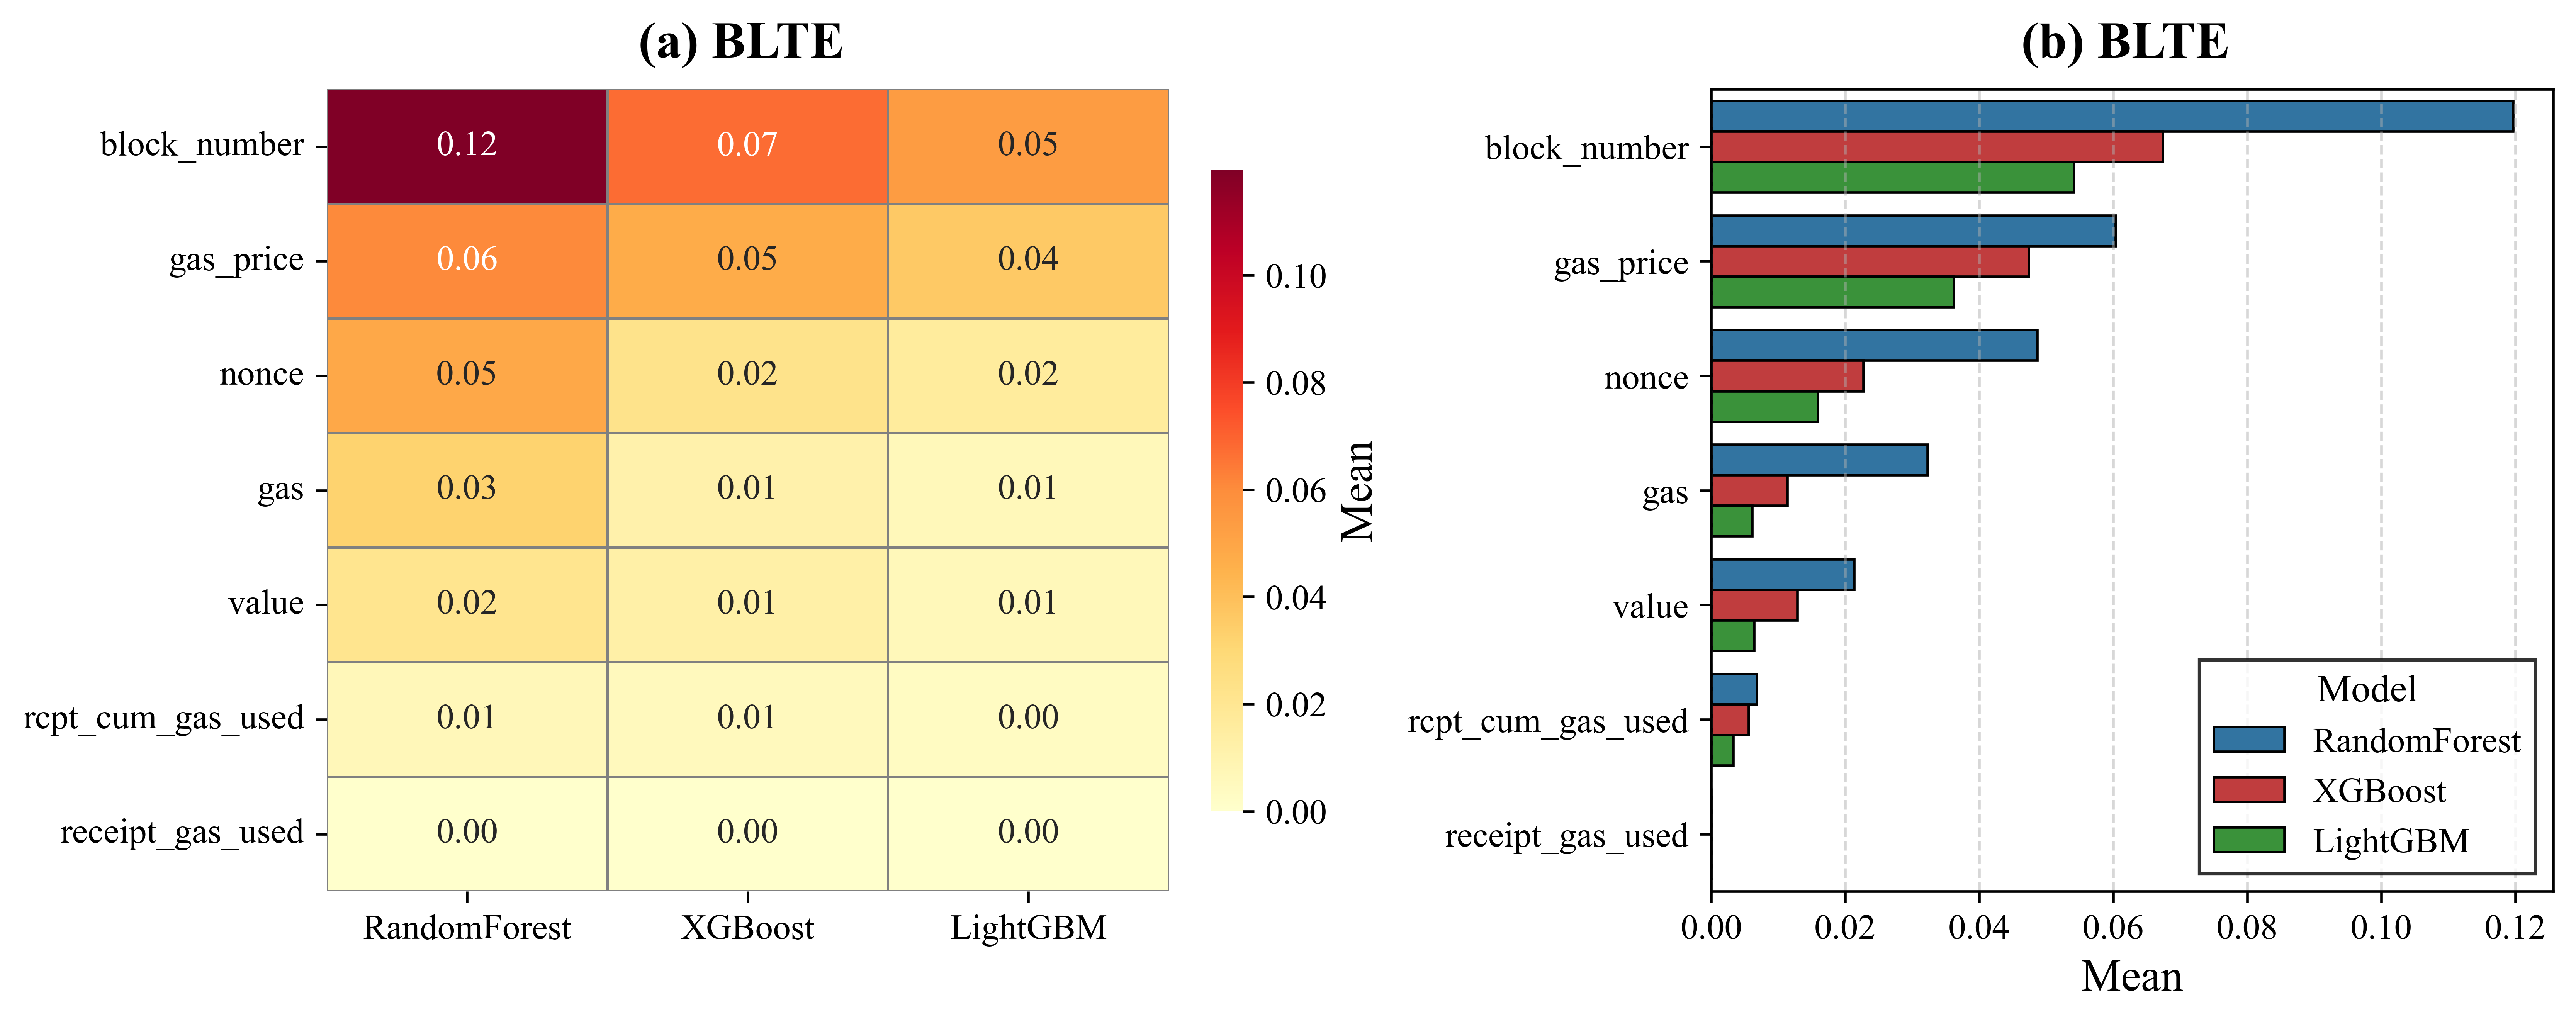

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 18


plt.close('all')


fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4.3),   
    dpi=600,
    constrained_layout=True
)
ax0, ax1 = axes


sns.heatmap(
    df_mean,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Mean", "shrink": 0.8},
    ax=ax0,
    annot_kws={"size": 11}
)

ax0.set_title("(a) BLTE ", pad=10, fontweight='bold')
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_yticklabels(df_mean.index, rotation=0)
ax0.set_xticklabels(df_mean.columns, rotation=0)


df_long = (
    df_mean
    .reset_index()
    .melt(id_vars="index", var_name="Model", value_name="Importance")
    .rename(columns={"index": "Feature"})
)


feature_order = df_mean.index.tolist()

sns.barplot(
    data=df_long,
    x="Importance",
    y="Feature",
    hue="Model",
    order=feature_order,
    palette=["#1f77b4", "#d62728", "#2ca02c"],   
    ax=ax1,
    edgecolor='black',
    linewidth=0.8
)

ax1.set_title("(b) BLTE ", pad=10, fontweight='bold')
ax1.set_xlabel("Mean")
ax1.set_ylabel("")
ax1.grid(axis="x", linestyle='--', alpha=0.5)

ax1.legend(
    title="Model",
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

fig.savefig("blte.png", dpi=600, bbox_inches="tight")


In [22]:
from pathlib import Path
import pandas as pd
from sklearn.metrics import f1_score

rows = []


base_models = {"RF": best_rf, "XGB": best_xgb, "LGBM": best_lgbm}
for name, model in base_models.items():
    y_pred = model.predict(X_test_scaled)
    rows.append({
        "seed": int(RANDOM_STATE),
        "model": name,
        "f1_macro": float(f1_score(y_test, y_pred, average="macro"))
    })


if "results_df" in globals():
    tmp = results_df.copy()
    tmp["model"] = tmp["ensemble"].astype(str) + "_" + tmp["voting"].astype(str)
    for _, r in tmp.iterrows():
        rows.append({
            "seed": int(RANDOM_STATE),
            "model": str(r["model"]),
            "f1_macro": float(r["f1_macro"])
        })



out_csv = Path(r"D:\elliptic\blte\blte\runs\macro_f1_all_models_by_seed.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)

df_out = pd.DataFrame(rows)

write_header = (not out_csv.exists()) or out_csv.stat().st_size == 0
df_out.to_csv(out_csv, mode="a", header=write_header, index=False)

print("Saved:", out_csv, "| rows:", len(df_out))


Saved: D:\elliptic\blte\blte\runs\macro_f1_all_models_by_seed.csv | rows: 65


d:\elliptic\venv1\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [23]:
import os

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

csv_path = os.path.join(out_dir, "ensemble_results.csv")
results_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("Saved:", csv_path)

Saved: outputs\ensemble_results.csv
